# 🛒 Big Mart Sales Prediction

This notebook predicts the sales of products at different Big Mart outlets using **Machine Learning**.

## 📊 Steps Covered
1. **Data Preprocessing**
   - Handling missing values
   - Encoding categorical variables
   - Outlier detection & scaling

2. **Exploratory Data Analysis (EDA)**
   - Distribution of sales
   - Feature correlations
   - Trends across outlets and items

3. **Model Building**
   - Train-Test split
   - Regression models (Linear Regression, Random Forest, XGBoost)
   - Performance evaluation (R² Score)

4. **Results**
   - Best performing model identified
   - Predictions for unseen data

## 🚀 Objective
To build a predictive model that helps Big Mart forecast product sales, optimize inventory, and improve business decisions.

In [34]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn import metrics
sns.set()

In [35]:
mall_data = pd.read_csv('train.csv')
mall_data.head()


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [36]:
mall_data.tail()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976
8522,DRG01,14.800,Low Fat,0.044878,Soft Drinks,75.4670,OUT046,1997,Small,Tier 1,Supermarket Type1,765.6700


In [37]:
pd.options.display.max_columns = None
pd.options.display.max_rows = None
display(mall_data)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350


In [38]:
mall_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [39]:
mall_data.shape

(8523, 12)

In [40]:
mall_data.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [41]:
 mall_data['Item_Weight'] = mall_data['Item_Weight'].fillna(mall_data['Item_Weight'].mean())

In [42]:
mall_data.isnull().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [43]:
mall_data['Outlet_Size'].mode()

0    Medium
Name: Outlet_Size, dtype: object

In [44]:
mall_data['Outlet_Size'] = mall_data['Outlet_Size'].fillna(mall_data['Outlet_Size'].mode()[0])



In [45]:
mall_data.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [46]:
mall_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [47]:
mall_data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


<Figure size 800x800 with 0 Axes>

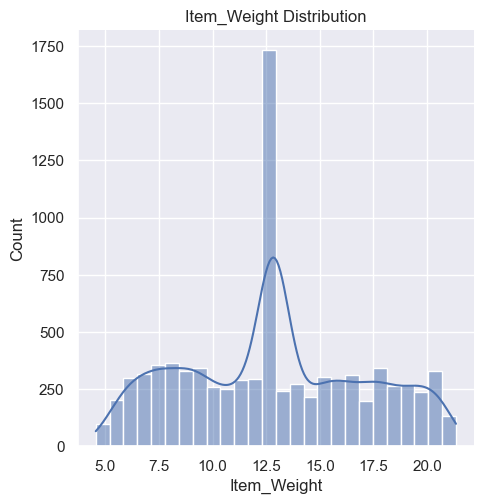

In [48]:
plt.figure(figsize = (8,8))
sns.displot(mall_data['Item_Weight'], kde = True)
plt.title('Item_Weight Distribution')
plt.show()

<Figure size 800x800 with 0 Axes>

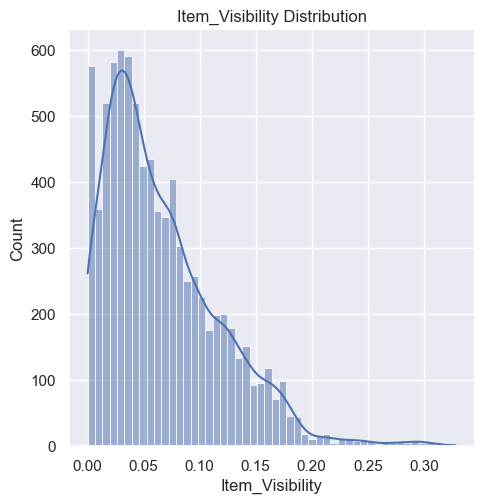

In [49]:
plt.figure(figsize = (8,8))
sns.displot(mall_data['Item_Visibility'], kde = True)
plt.title('Item_Visibility Distribution')
plt.show()

<Figure size 800x800 with 0 Axes>

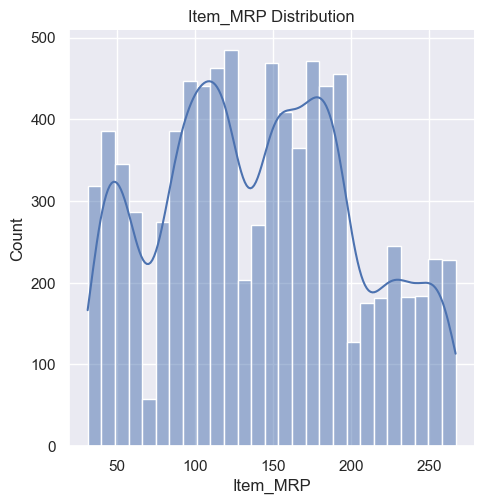

In [50]:
plt.figure(figsize = (8,8))
sns.displot(mall_data['Item_MRP'], kde = True)
plt.title('Item_MRP Distribution')
plt.show()

<Figure size 800x800 with 0 Axes>

C:\Users\vinayak\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


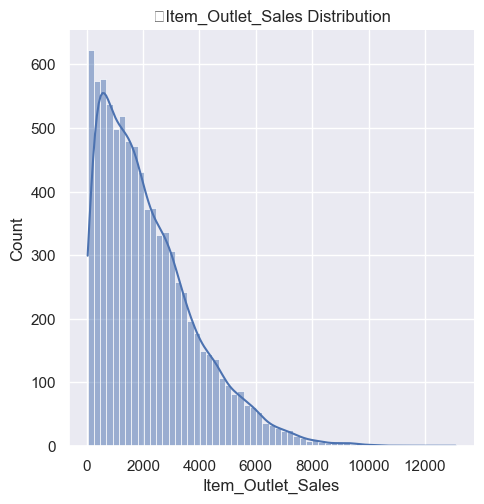

In [52]:
plt.figure(figsize = (8,8))
sns.displot(mall_data['Item_Outlet_Sales'], kde = True)
plt.title('	Item_Outlet_Sales Distribution')
plt.show()

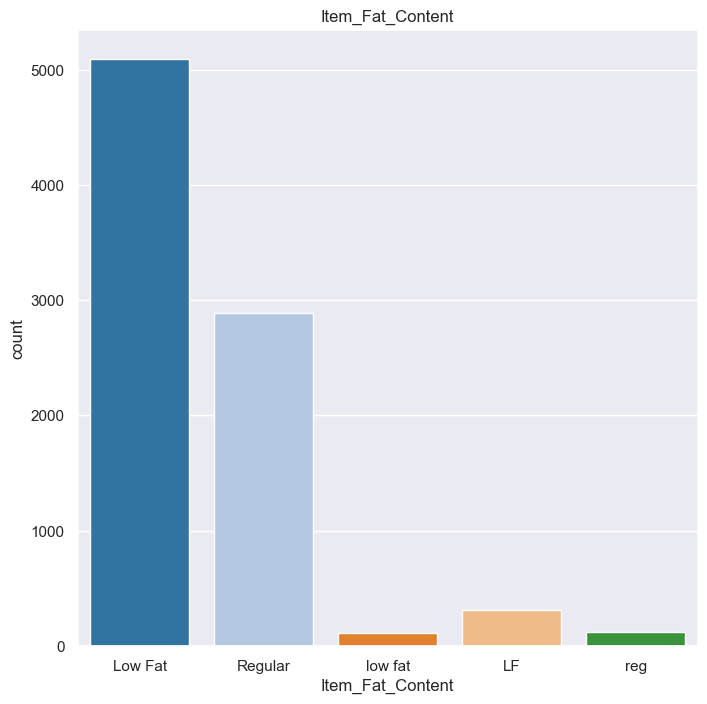

In [60]:
plt.figure(figsize =(8,8))
sns.countplot(x = 'Item_Fat_Content',  hue= 'Item_Fat_Content', data = mall_data, palette = 'tab20', legend=False )
plt.title('Item_Fat_Content')
plt.show()

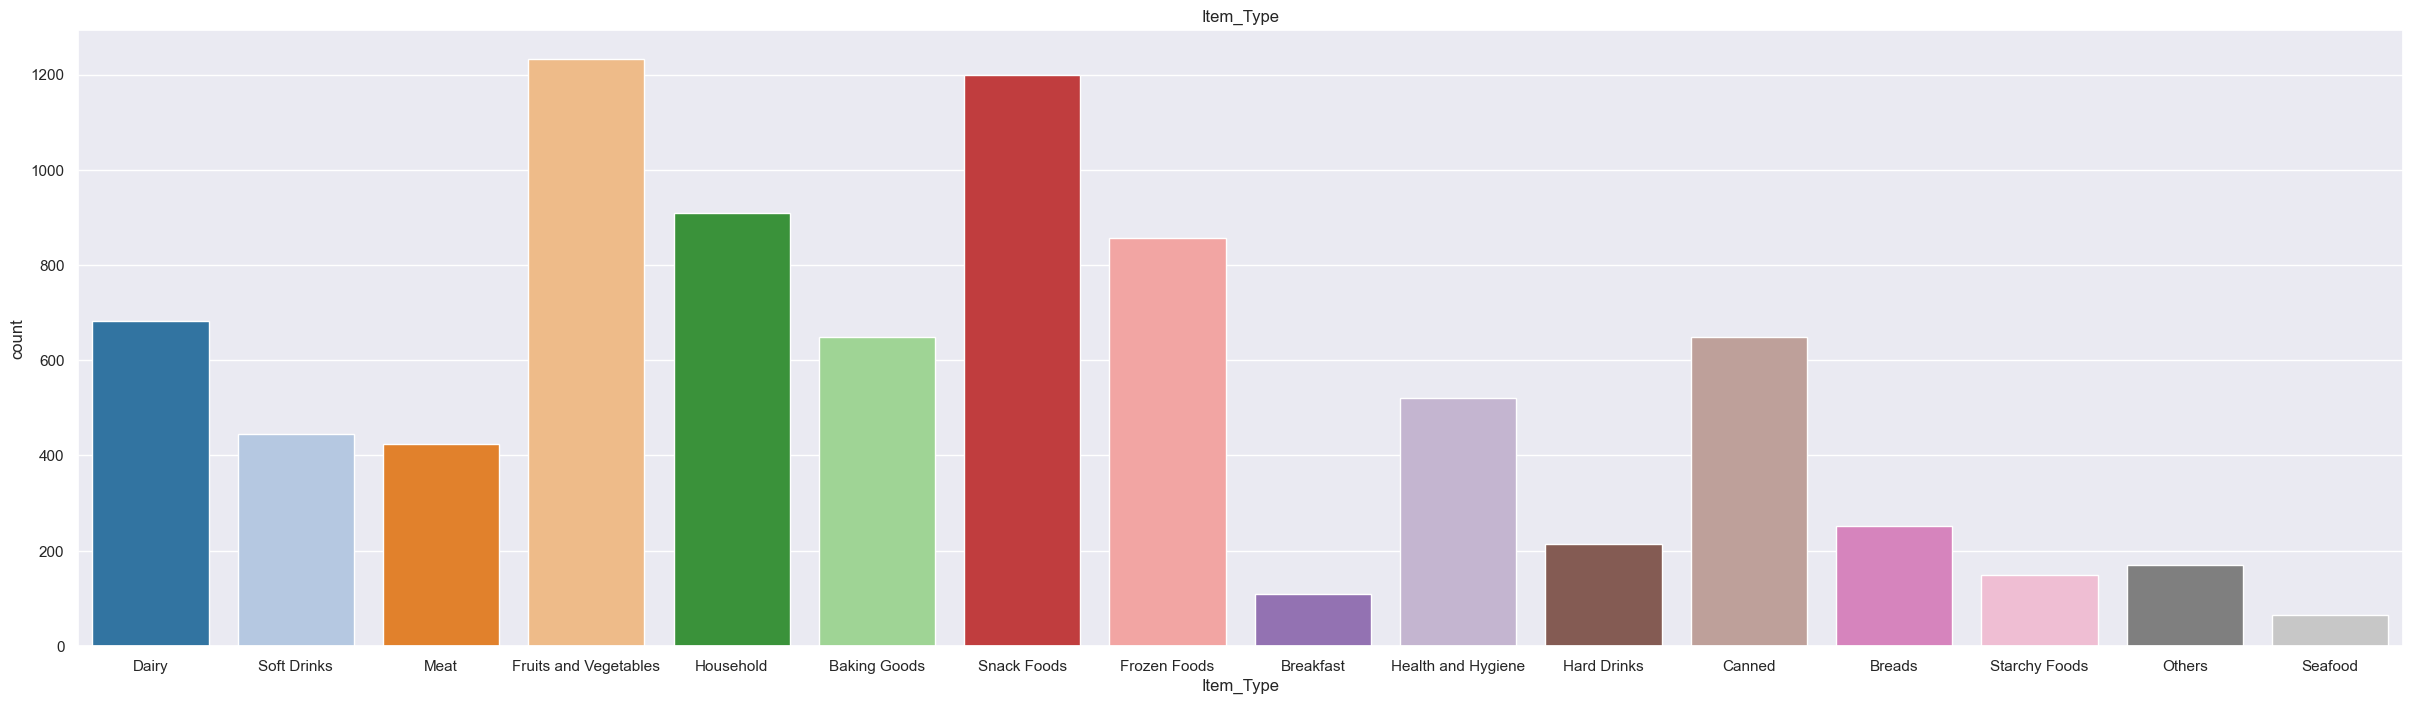

In [57]:
plt.figure(figsize=(30,8))
sns.countplot(x='Item_Type', hue='Item_Type', data=mall_data, palette="tab20", legend=False)
plt.title('Item_Type')
plt.show()



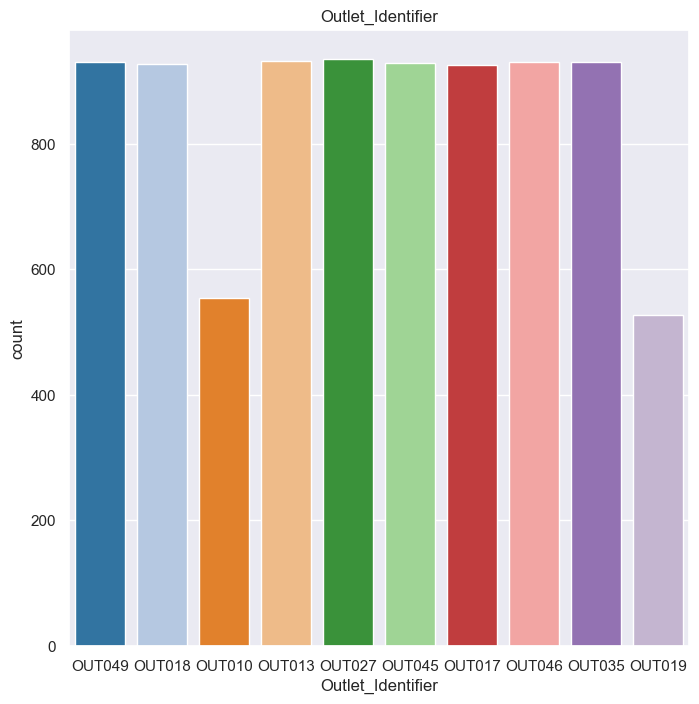

In [61]:
plt.figure(figsize =(8,8))
sns.countplot(x = 'Outlet_Identifier',hue= 'Outlet_Identifier', data = mall_data, palette = 'tab20',legend = False)
plt.title('Outlet_Identifier')
plt.show()

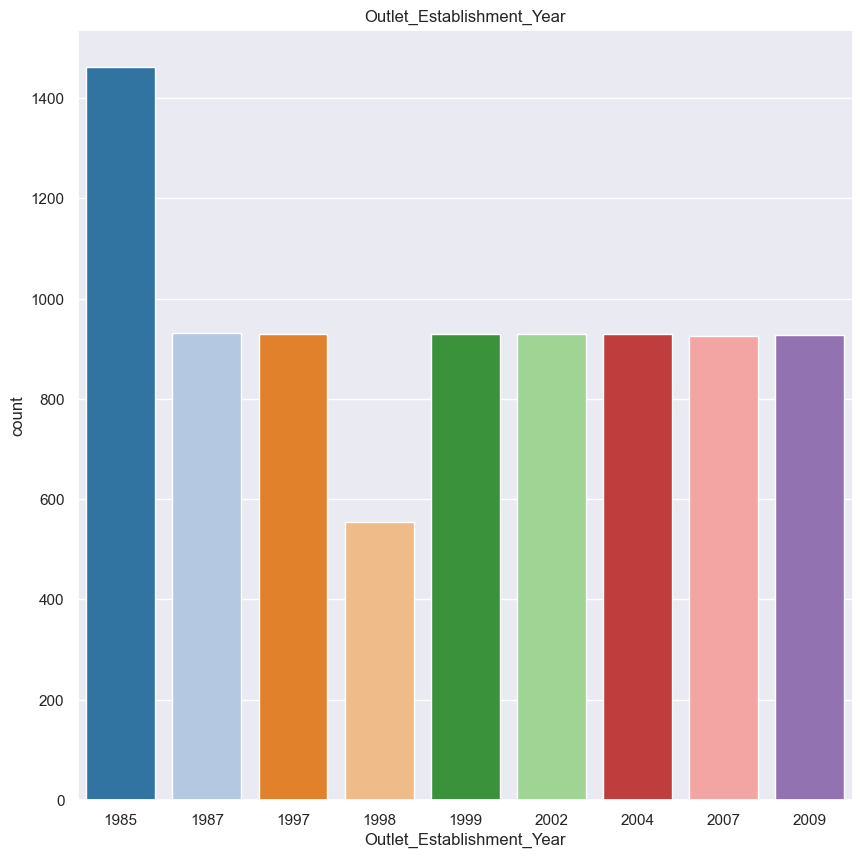

In [75]:
plt.figure(figsize =(10,10))
sns.countplot(x = 'Outlet_Establishment_Year',hue = 'Outlet_Establishment_Year', data = mall_data, palette = 'tab20',legend = False)
plt.title('Outlet_Establishment_Year')
plt.show()

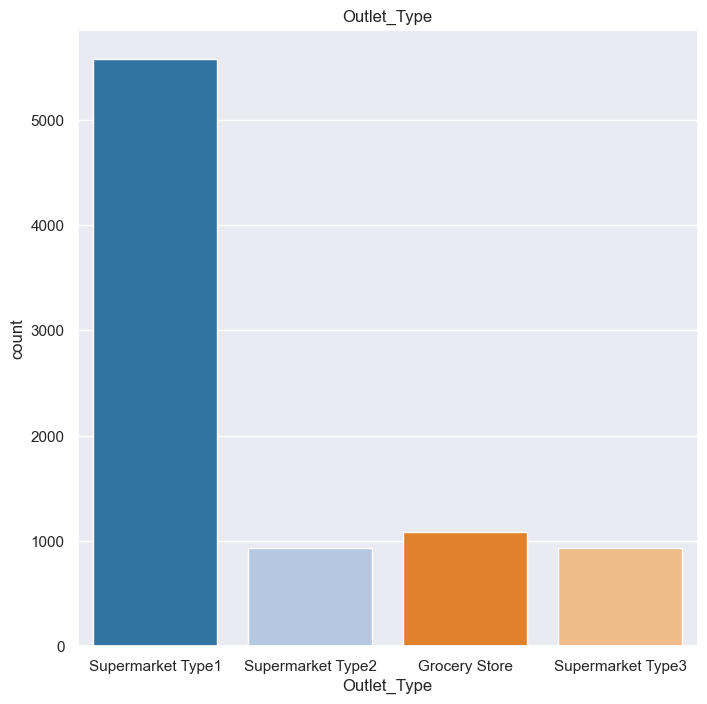

In [63]:
plt.figure(figsize =(8,8))
sns.countplot(x = 'Outlet_Type',hue = 'Outlet_Type', palette = 'tab20', data = mall_data, legend = False)
plt.title('Outlet_Type')
plt.show()

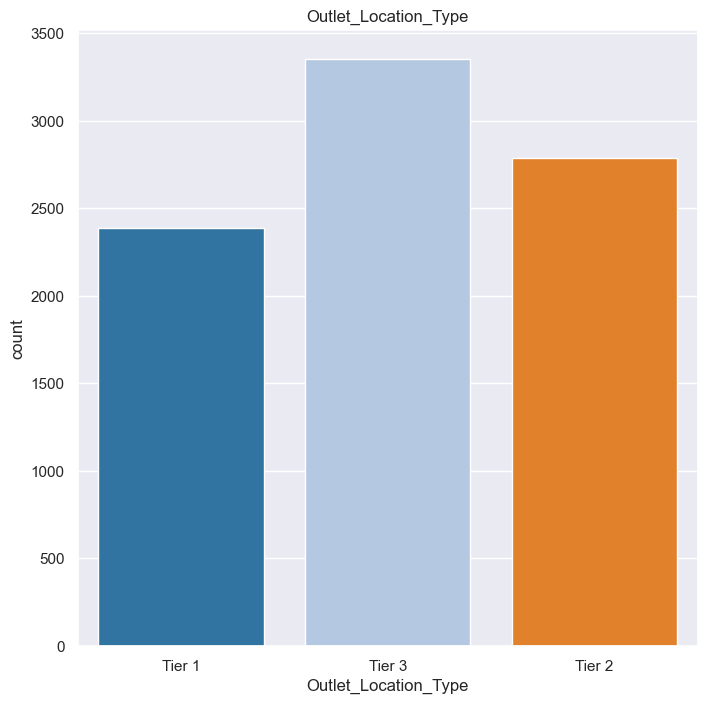

In [64]:
plt.figure(figsize =(8,8))
sns.countplot(x = 'Outlet_Location_Type',hue = 'Outlet_Location_Type', data = mall_data, palette = 'tab20',legend = False)
plt.title('Outlet_Location_Type')
plt.show()

In [66]:
encoder = LabelEncoder()


In [67]:
mall_data['Item_Identifier'] = encoder.fit_transform(mall_data['Item_Identifier'])

In [68]:
mall_data['Item_Fat_Content'] = encoder.fit_transform(mall_data['Item_Fat_Content'])

In [69]:
mall_data['Item_Type'] = encoder.fit_transform(mall_data['Item_Type'])

In [70]:
mall_data['Outlet_Identifier'] = encoder.fit_transform(mall_data['Outlet_Identifier'])

In [71]:
mall_data['Outlet_Size'] = encoder.fit_transform(mall_data['Outlet_Size'])

In [72]:
mall_data['Outlet_Location_Type'] = encoder.fit_transform(mall_data['Outlet_Location_Type'])

In [73]:
mall_data['Outlet_Type'] = encoder.fit_transform(mall_data['Outlet_Type'])

In [74]:
mall_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,156,9.30,1,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,8,5.92,2,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,662,17.50,1,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,1121,19.20,2,0.000000,6,182.0950,0,1998,1,2,0,732.3800
4,1297,8.93,1,0.000000,9,53.8614,1,1987,0,2,1,994.7052


In [77]:
x = mall_data.drop( columns = 'Item_Outlet_Sales', axis = 1)
y = mall_data['Item_Outlet_Sales']

In [78]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 2)

In [79]:
print(x.shape,x_train.shape,x_test.shape)

(8523, 11) (6818, 11) (1705, 11)


In [80]:
regressor = XGBRegressor()
regressor.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [82]:
x_train_prediction = regressor.predict(x_train)
print(x_train_prediction)

[1822.0797 2827.2998 3160.4617 ... 2797.9402 2051.2676 1775.733 ]


In [84]:
r2_pred = metrics.r2_score(x_train_prediction,y_train)
print(r2_pred)

0.8351243769069658
